# Figure 3b–h — Tg motif screening analysis

This notebook recreates the data-analysis panels of manuscript Figure 3 for **Tg**.
It reads the saved screening outputs only and does not retrain a model. Every plotting cell
displays its panel and writes an editable SVG into the figure3_analysis folder.


In [1]:
# 0. Adjustable parameters — modify values here for all panels in this notebook
from pathlib import Path
import sys
from IPython.display import display

NOTEBOOK_DIR = Path.cwd() / 'LCMWR' / 'scripts' / 'feature_selection'
if NOTEBOOK_DIR.exists() and str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from figure3_motif_panels import (
    STYLE, apply_style, load_task_data, plot_distribution, plot_atom_number_frequency,
    plot_search, plot_stepwise, plot_umap,
)

TASK = 'tg'
TASK_LABEL = 'Tg'
METRIC_LABEL = 'R²'

# ----- Typography and geometry (pt/in) -----
FONT_FAMILY = 'Arial'             # Manuscript font; Matplotlib uses a fallback if Arial is unavailable
FONT_SIZE = 9                     # Tick labels and legend text (pt)
AXIS_LABEL_SIZE = 10              # Axis-label/title text (pt)
PANEL_LABEL_SIZE = 13             # Panel letter, e.g. '(b)' (pt)
LINE_WIDTH = 1.2                  # Axis and curve width
TICK_WIDTH = 1.2                  # Tick-mark width
FIGURE_DPI = 180                  # Inline notebook preview only; SVG output is vector
TRANSPARENT_BACKGROUND = True     # Keep SVG backgrounds transparent

# ----- Figure 3 colour palette -----
BLUE = '#73A9CC'
LIGHT_BLUE = '#B7D1E5'
DARK_BLUE = '#4A7899'
ORANGE = '#F29B6D'
GREY = '#B7B7B7'
BLACK = '#222222'

# ----- Data/UMAP controls -----
HISTOGRAM_BINS = 20
VOCAB_FIGURE_WIDTH = 11.05          # b/c：长图整体宽度（in）；原值的 1.7 倍
VOCAB_FIGURE_HEIGHT = 4.59          # b/c：长图整体高度（in）；原值的 1.7 倍
VOCAB_FRAME_RATIO = 525 / 180       # b/c：坐标框宽:高，参考论文长条比例
VOCAB_BAR_WIDTH = 0.96              # b/c：每个 vocab 柱条宽度
ATOM_GRADIENT_TOP = '#EAF3F8'       # d/e：柱条顶部渐变颜色
ATOM_COUNT_LABEL_SIZE = 8           # d/e：柱顶数量字号（pt）
ATOM_COUNT_LABEL_OFFSET = 3         # d/e：柱顶数量上移距离（pt）
UMAP_RANDOM_STATE = 48
UMAP_N_NEIGHBORS = 5
UMAP_MIN_DIST = 0.8
UMAP_METRIC = 'euclidean'
UMAP_INIT = 'random'
RECOMPUTE_UMAP = False            # True: recalculate coordinates; False: reuse saved coordinates
UMAP_FIGURE_WIDTH = 4.2           # f：UMAP 画幅宽度（in）
UMAP_FIGURE_HEIGHT = 3.4          # f：UMAP 画幅高度（in）
UMAP_OTHER_SIZE = 12              # f：未筛选 motif 空心点大小
UMAP_SELECTED_SIZE = 16           # f：筛选 motif 空心点大小
UMAP_AXIS_PADDING_FRACTION = 0.10 # f：点云与 x/y 框线四周的留白比例
UMAP_SHOW_TITLE = False            # f：False 时隐藏/注释上方标题
STEPWISE_METRIC_LOW_FRACTION = 0.20   # 折线最低点位于右轴高度的 20%
STEPWISE_METRIC_HIGH_FRACTION = 0.80  # 折线最高点位于右轴高度的 80%
STEPWISE_LABEL_ROTATION = 30          # 五个筛选步骤标签的倾斜角度
STEPWISE_LABEL_RIGHT_SHIFT = 0.0      # h：标签横向位移（数据坐标）
STEPWISE_LABEL_Y_OFFSET = -0.045      # h：标签距下框线的相对位置；越接近 0 越靠近框线
STEPWISE_XLABEL_LABELPAD = 35         # h：Selection Step 与斜标签的间距（pt）
STEPWISE_FIGURE_HEIGHT = 3.55         # h：增加下方留白后的画幅高度（in）
SEARCH_POINT_SIZE = 18                # g：750 组合散点大小
SEARCH_POINT_EDGE_WIDTH = 0.35        # g：散点黑色描边宽度
ATOM_NUMBER_WIDTH_PER_BAR = 0.22      # d/e：每个 Atom Number 对应的画幅宽度（in）
ATOM_NUMBER_TICK_SIZE = 8             # d/e：逐一显示的 Atom Number 刻度字号（pt）

STYLE.update({
    'font_family': FONT_FAMILY, 'font_size': FONT_SIZE,
    'axis_label_size': AXIS_LABEL_SIZE, 'panel_label_size': PANEL_LABEL_SIZE,
    'line_width': LINE_WIDTH, 'tick_width': TICK_WIDTH, 'figure_dpi': FIGURE_DPI,
    'transparent_background': TRANSPARENT_BACKGROUND,
    'blue': BLUE, 'light_blue': LIGHT_BLUE, 'dark_blue': DARK_BLUE,
    'orange': ORANGE, 'grey': GREY, 'black': BLACK,
    'histogram_bins': HISTOGRAM_BINS,
    'vocab_figure_width': VOCAB_FIGURE_WIDTH, 'vocab_figure_height': VOCAB_FIGURE_HEIGHT,
    'vocab_frame_width_to_height': VOCAB_FRAME_RATIO, 'vocab_bar_width': VOCAB_BAR_WIDTH,
    'atom_number_gradient_top': ATOM_GRADIENT_TOP,
    'atom_number_count_label_size': ATOM_COUNT_LABEL_SIZE,
    'atom_number_count_label_offset': ATOM_COUNT_LABEL_OFFSET,
    'umap_random_state': UMAP_RANDOM_STATE,
    'umap_n_neighbors': UMAP_N_NEIGHBORS, 'umap_min_dist': UMAP_MIN_DIST,
    'umap_metric': UMAP_METRIC, 'umap_init': UMAP_INIT,
    'recompute_umap': RECOMPUTE_UMAP,
    'umap_figure_width': UMAP_FIGURE_WIDTH, 'umap_figure_height': UMAP_FIGURE_HEIGHT,
    'umap_other_size': UMAP_OTHER_SIZE, 'umap_selected_size': UMAP_SELECTED_SIZE,
    'umap_axis_padding_fraction': UMAP_AXIS_PADDING_FRACTION,
    'umap_show_title': UMAP_SHOW_TITLE,
    'stepwise_metric_low_fraction': STEPWISE_METRIC_LOW_FRACTION,
    'stepwise_metric_high_fraction': STEPWISE_METRIC_HIGH_FRACTION,
    'stepwise_label_rotation': STEPWISE_LABEL_ROTATION,
    'stepwise_label_right_shift': STEPWISE_LABEL_RIGHT_SHIFT,
    'stepwise_label_y_offset': STEPWISE_LABEL_Y_OFFSET,
    'stepwise_xlabel_labelpad': STEPWISE_XLABEL_LABELPAD,
    'stepwise_figure_height': STEPWISE_FIGURE_HEIGHT,
    'search_point_size': SEARCH_POINT_SIZE,
    'search_point_edge_width': SEARCH_POINT_EDGE_WIDTH,
    'atom_number_width_per_bar': ATOM_NUMBER_WIDTH_PER_BAR,
    'atom_number_tick_size': ATOM_NUMBER_TICK_SIZE,
})
apply_style(STYLE)


In [2]:
# 1. Load saved screening data and write a compact numerical summary
data = load_task_data(TASK, STYLE)
display(data['summary'])
print(f"SVG output folder: {data['paths']['output_dir']}")


## Panels (b–e): motif-property distributions


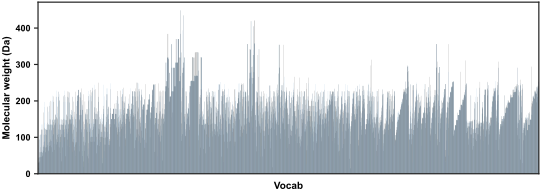

In [3]:
# (b) Molecular-weight distribution before task-specific selection
plot_distribution(data, 'molecular_weight', selected=False, panel='b', style=STYLE)


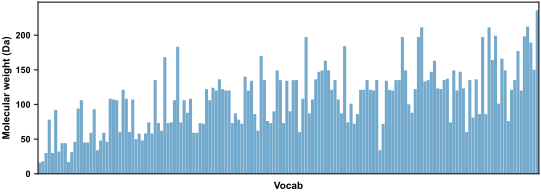

In [4]:
# (c) Molecular-weight distribution after task-specific selection
plot_distribution(data, 'molecular_weight', selected=True, panel='c', style=STYLE)


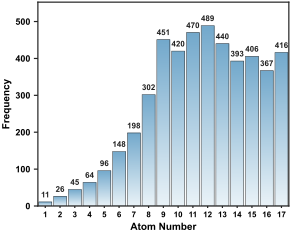

In [5]:
# (d) Frequency of atom numbers before task-specific selection
plot_atom_number_frequency(data, selected=False, panel='d', style=STYLE)


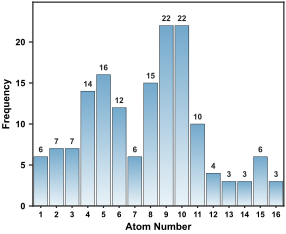

In [6]:
# (e) Frequency of atom numbers after task-specific selection
plot_atom_number_frequency(data, selected=True, panel='e', style=STYLE)


## Panel (f): motif feature-space UMAP


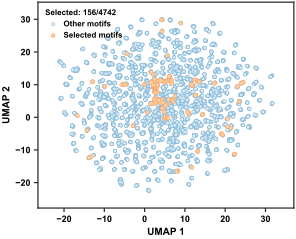

In [7]:
# (f) UMAP of motif profiles across samples; orange marks final selected motifs
plot_umap(data, STYLE)


## Panel (g): complete 750-combination search


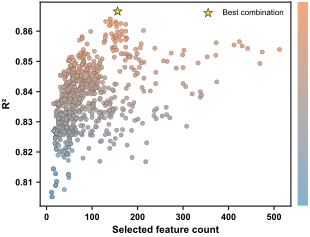

In [8]:
# (g) Performance versus feature count; the star marks the best threshold combination
plot_search(data, STYLE)


## Panel (h): stepwise screening trajectory


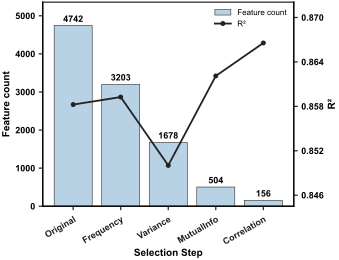

In [9]:
# (h) Bars show feature count and the line shows the task-specific screening metric
plot_stepwise(data, STYLE)


In [10]:
# 2. Confirm all Figure 3b–h vector assets are present
svg_assets = sorted(data['paths']['output_dir'].glob('Figure3*.svg'))
for asset in svg_assets:
    print(asset.name)
assert len(svg_assets) >= 7, 'Expected one SVG for each Figure 3b–h panel.'
